# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

This project investigates how tech occupation salaries vary across U.S. metropolitan areas and how those salaries relate to local cost of living. Understanding this relationship is critical for both employers making location-based hiring decisions and professionals evaluating where to maximize their earning power. To answer this question, I will wrangle two real-world datasets: occupational wage data by metro area from the U.S. Bureau of Labor Statistics OEWS May 2024 release, gathered via manual download, and cost of living index data for 2025 scraped from Numbeo using BeautifulSoup. The combined dataset will allow me to identify which U.S. cities offer the best compensation value for tech workers when accounting for local cost of living.

### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1**

Type:
BLS Occupational Employment & Wage Statistics (ZIP/Excel)

Method: 
The data was gathered using the "Download data manually" method from the U.S. Bureau of Labor Statistics website (bls.gov). This dataset contains occupational employment and wage estimates for approximately 530 U.S. metropolitan areas, making it ideal for analyzing how tech worker compensation varies geographically across the country.
Dataset variables:

*   *OCC_TITLE*  : The occupation title (e.g., Software Developers, Data Scientists)
*   *A_MEDIAN*   : Annual median wage for the occupation in that metro area
*   *AREA_TITLE* : The name of the metropolitan statistical area (e.g., Austin, TX)
*   *TOT_EMP*    : Total number of employees in that occupation and area

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -------------------------------------------------------
# Dataset 1: BLS Occupational Employment & Wage Statistics
# Gathering Method: Manual download from bls.gov
# Source: U.S. Bureau of Labor Statistics
# -------------------------------------------------------

# Load the BLS OEWS metro area dataset
bls_df = pd.read_excel('MSA_M2024_dl.xlsx')

# Preview the data
print(f"Shape: {bls_df.shape}")
print(f"\nColumns: {bls_df.columns.tolist()}")
bls_df.head()

Shape: (150176, 32)

Columns: ['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE', 'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP', 'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT', 'H_MEAN', 'A_MEAN', 'MEAN_PRSE', 'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90', 'ANNUAL', 'HOURLY']


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,10180,"Abilene, TX",4,TX,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,20.25,29.34,45.3,23120,29640,42120,61020,94220,NaN,NaN
1,10180,"Abilene, TX",4,TX,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,42.03,61.17,84.3,44710,61250,87420,127230,175350,NaN,NaN
2,10180,"Abilene, TX",4,TX,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,85.35,#,#,99140,107040,177520,#,#,NaN,NaN
3,10180,"Abilene, TX",4,TX,0,Cross-industry,cross-industry,1235,11-1021,General and Operations Managers,...,37.18,58.64,87.22,35980,50640,77340,121970,181420,NaN,NaN
4,10180,"Abilene, TX",4,TX,0,Cross-industry,cross-industry,1235,11-2021,Marketing Managers,...,50.02,73.86,99.9,58480,82560,104030,153630,207790,NaN,NaN


#### Dataset 2

Type: *HTML Web Scrape (CSV)* 

Method: *The data was gathered using the "Gather and extract data from HTML files using BeautifulSoup" method from website (numbeo.com). Numbeo is the world's largest crowd-sourced database of city and country cost of living data, making it a reliable source for comparing living expenses across U.S. cities.* 

Dataset variables:

*   *City* : The name of the city (our join key to the BLS dataset)

*   *Cost of Living Index* : A relative indicator of consumer goods prices including groceries, restaurants, transportation and utilities

*   *Rent Index* : A relative indicator of apartment rental costs in the city

*   *Local Purchasing Power Index* : An indicator of purchasing power relative to the average net salary in that city

In [2]:
#Second data gathering and loading method
import requests
from bs4 import BeautifulSoup
import pandas as pd

# -------------------------------------------------------
# Dataset 2: Numbeo Cost of Living Index by City 2025
# Gathering Method: Web scraping using BeautifulSoup
# Source: numbeo.com
# -------------------------------------------------------

url = "https://www.numbeo.com/cost-of-living/rankings.jsp?title=2025&region=021"
headers = {"User-Agent": "Mozilla/5.0"}

# Fetch the page
response = requests.get(url, headers=headers)

# Parse HTML with BeautifulSoup
soup = BeautifulSoup(response.text, "html.parser")

# Find the main data table
table = soup.find("table", {"id": "t2"})

# Extract headers
headers_list = [th.text.strip() for th in table.find_all("th")]

# Extract rows
rows = []
for tr in table.find_all("tr")[1:]:
    cells = [td.text.strip() for td in tr.find_all("td")]
    if cells:
        rows.append(cells)

# Create DataFrame
numbeo_df = pd.DataFrame(rows, columns=headers_list)

# Filter to US cities only
numbeo_df = numbeo_df[numbeo_df["City"].str.contains("United States", na=False)]

# Clean city name - remove ", United States"
numbeo_df["City"] = numbeo_df["City"].str.replace(", United States", "", regex=False).str.strip()

print(f"Shape: {numbeo_df.shape}")
numbeo_df.head(10)

Shape: (38, 8)


,Rank,City,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
3,,"New York, NY",100.0,100.0,100.0,100.0,100.0,100.0
6,,"San Francisco, CA",90.5,78.0,85.0,103.6,90.3,156.6
7,,"Honolulu, HI",86.9,57.4,73.8,105.1,81.7,103.5
9,,"Boston, MA",83.7,75.2,79.9,92.3,90.4,127.3
11,,"Seattle, WA",78.9,58.1,69.7,88.1,80.6,172.9
12,,"Washington, DC",78.7,66.9,73.5,83.3,85.3,144.5
14,,"San Diego, CA",77.9,67.1,73.1,77.1,80.8,139.6
16,,"Los Angeles, CA",76.3,62.9,70.4,81.1,89.2,123.3
18,,"Sacramento, CA",76.0,49.6,64.3,85.1,72.7,128.7
20,,"Philadelphia, PA",73.9,41.3,59.5,88.4,72.0,125.0


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [3]:
#Optional: store the raw data in your local data store
# -------------------------------------------------------
# Store raw datasets locally before cleaning
# -------------------------------------------------------

# Save raw BLS data
bls_df.to_csv('raw_bls_wages.csv', index=False)

# Save raw Numbeo data
numbeo_df.to_csv('raw_numbeo_cost_of_living.csv', index=False)

print("Raw datasets saved successfully!")
print(f"raw_bls_wages.csv - {bls_df.shape[0]} rows")
print(f"raw_numbeo_cost_of_living.csv - {numbeo_df.shape[0]} rows")

Raw datasets saved successfully!
raw_bls_wages.csv - 150176 rows
raw_numbeo_cost_of_living.csv - 38 rows


## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1:

In [4]:
# Inspecting the dataframe visually
# Quality Issue 1: Missing/suppressed values in BLS wage data
# Visual inspection - checking for '#' suppressed values
bls_df[['AREA_TITLE', 'OCC_TITLE', 'A_MEDIAN', 'TOT_EMP']].head(20)

,AREA_TITLE,OCC_TITLE,A_MEDIAN,TOT_EMP
0,"Abilene, TX",All Occupations,42120,74090
1,"Abilene, TX",Management Occupations,87420,5420
2,"Abilene, TX",Chief Executives,177520,50
3,"Abilene, TX",General and Operations Managers,77340,2240
4,"Abilene, TX",Marketing Managers,104030,140
5,"Abilene, TX",Sales Managers,118610,310
6,"Abilene, TX",Public Relations Managers,78830,50
7,"Abilene, TX",Administrative Services Managers,100480,110
8,"Abilene, TX",Facilities Managers,85010,60
9,"Abilene, TX",Computer and Information Systems Managers,129800,140


In [5]:
# Inspecting the dataframe programmatically
# Programmatic inspection - count suppressed '#' values in A_MEDIAN
suppressed = (bls_df['A_MEDIAN'] == '#').sum()
total = len(bls_df)

print(f"Total rows: {total}")
print(f"Suppressed '#' values in A_MEDIAN: {suppressed}")
print(f"Percentage suppressed: {round(suppressed/total*100, 2)}%")
print(f"\nData type of A_MEDIAN: {bls_df['A_MEDIAN'].dtype}")

Total rows: 150176
Suppressed '#' values in A_MEDIAN: 1063
Percentage suppressed: 0.71%

Data type of A_MEDIAN: object


Issue and justification: 
*The A_MEDIAN column in the BLS dataset contains 1,063 suppressed values represented as '#' instead of actual wage figures. The BLS uses this symbol to protect the confidentiality of employers when sample sizes are too small. This is a completeness issue because these missing values will prevent accurate numerical analysis and must be handled before any wage calculations can be performed. This was confirmed visually by inspecting the dataframe and programmatically by counting occurrences of '#' in the column, which also revealed that A_MEDIAN is stored as an object data type instead of numeric due to these non-numeric characters.*

### Quality Issue 2:

Issue and justification: *All numeric columns in the Numbeo dataset (Cost of Living Index, Rent Index, Groceries Index, etc.) are stored as object (string) data type instead of float. This is a validity issue because these columns contain numerical index values that need to be in numeric format for any mathematical operations, comparisons, or visualizations to work correctly. This was confirmed visually by inspecting the dataframe where values appeared numeric, and programmatically using dtypes which revealed all columns are object type, with individual values confirmed as str class.*

In [6]:
# Inspecting the dataframe programmatically
# Programmatic inspection - check data types of Numbeo dataset
print("Numbeo DataFrame dtypes:")
print(numbeo_df.dtypes)
print(f"\nSample values in 'Cost of Living Index': {numbeo_df['Cost of Living Index'].tolist()[:5]}")
print(f"Type of first value: {type(numbeo_df['Cost of Living Index'].iloc[0])}")

Numbeo DataFrame dtypes:
Rank                              object
City                              object
Cost of Living Index              object
Rent Index                        object
Cost of Living Plus Rent Index    object
Groceries Index                   object
Restaurant Price Index            object
Local Purchasing Power Index      object
dtype: object

Sample values in 'Cost of Living Index': ['100.0', '90.5', '86.9', '83.7', '78.9']
Type of first value: <class 'str'>


### Tidiness Issue 1: The BLS dataset contains both hourly and annual wage columns for the same measurement, creating redundant variables

In [7]:
# Inspecting the dataframe visually
# Visual inspection - check the raw BLS dataset structure
# Tidiness Issue 1: BLS dataset has redundant hourly AND annual wage columns
# for the same measurements - this violates tidy data principles
# Visual inspection - check redundant wage columns

wage_columns = [col for col in bls_df.columns if col.startswith('H_') or col.startswith('A_')]
print("Hourly wage columns:")
print([col for col in wage_columns if col.startswith('H_')])
print("\nAnnual wage columns:")
print([col for col in wage_columns if col.startswith('A_')])
print(f"\nSample data showing redundancy:")
bls_df[['OCC_TITLE', 'H_MEDIAN', 'A_MEDIAN', 'H_MEAN', 'A_MEAN']].head()

# Filter BLS data to tech-related occupations only
# This removes irrelevant occupations before combining datasets

tech_keywords = ['Software', 'Computer', 'Data Scientist', 
                 'Network', 'Database', 'Developer',
                 'Programmer', 'Information Security',
                 'Web Developer', 'Cloud', 'Cybersecurity',
                 'Computer Systems', 'Computer and Information',
                 'Operations Research Analyst']

Hourly wage columns:
['H_MEAN', 'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90']

Annual wage columns:
['A_MEAN', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90']

Sample data showing redundancy:


In [8]:
# Programmatic inspection - confirm redundancy between hourly and annual columns
import numpy as np

# Annual wage should equal hourly wage × 2080 work hours per year
bls_df['calculated_annual'] = pd.to_numeric(bls_df['H_MEDIAN'], errors='coerce') * 2080
bls_df['actual_annual'] = pd.to_numeric(bls_df['A_MEDIAN'], errors='coerce')

# Check correlation
valid = bls_df.dropna(subset=['calculated_annual', 'actual_annual'])
correlation = valid['calculated_annual'].corr(valid['actual_annual'])

print(f"Total hourly wage columns: {len([col for col in bls_df.columns if col.startswith('H_')])}")
print(f"Total annual wage columns: {len([col for col in bls_df.columns if col.startswith('A_')])}")
print(f"Total redundant wage columns: 12")
print(f"\nCorrelation between H_MEDIAN x 2080 and A_MEDIAN: {correlation:.4f}")
print("A correlation near 1.0 confirms these columns are redundant representations of the same data")

Total hourly wage columns: 6
Total annual wage columns: 6
Total redundant wage columns: 12

Correlation between H_MEDIAN x 2080 and A_MEDIAN: 1.0000
A correlation near 1.0 confirms these columns are redundant representations of the same data


Issue and justification: *The BLS dataset contains 12 redundant wage columns which are 6 hourly (H_MEAN, H_MEDIAN, H_PCT10, H_PCT25, H_PCT75, H_PCT90) and 6 annual (A_MEAN, A_MEDIAN, A_PCT10, A_PCT25, A_PCT75, A_PCT90)that represent the same measurements in different units. This is a tidiness issue because multiple variables are storing the same information, violating the tidy data principle that each variable should be stored in exactly one column. This was confirmed visually by inspecting the column names and programmatically by calculating the correlation between H_MEDIAN × 2080 and A_MEDIAN, which returned a perfect correlation of 1.0000, proving these columns are redundant representations of the same underlying data.*

### Tidiness Issue 2: Inconsistent city name formats between the BLS and Numbeo datasets prevent a direct join

In [9]:
# Inspecting the dataframe visually
# Tidiness Issue 2: City name format mismatch between datasets
# Visual inspection - compare city name formats
print("BLS city format examples:")
print(bls_df['AREA_TITLE'].unique()[:10])

print("\nNumbero city format examples:")
print(numbeo_df['City'].unique()[:10])

BLS city format examples:
['Abilene, TX' 'Aguadilla, PR' 'Akron, OH' 'Albany, GA' 'Albany, OR'
 'Albany-Schenectady-Troy, NY' 'Albuquerque, NM' 'Alexandria, LA'
 'Allentown-Bethlehem-Easton, PA-NJ' 'Altoona, PA']

Numbero city format examples:
['New York, NY' 'San Francisco, CA' 'Honolulu, HI' 'Boston, MA'
 'Seattle, WA' 'Washington, DC' 'San Diego, CA' 'Los Angeles, CA'
 'Sacramento, CA' 'Philadelphia, PA']


In [10]:
# Inspecting the dataframe programmatically
# Programmatic inspection - check how many cities match directly
bls_cities = set(bls_df['AREA_TITLE'].unique())
numbeo_cities = set(numbeo_df['City'].unique())

# Direct matches
direct_matches = bls_cities.intersection(numbeo_cities)
print(f"BLS unique cities: {len(bls_cities)}")
print(f"Numbeo unique cities: {len(numbeo_cities)}")
print(f"Direct matches without cleaning: {len(direct_matches)}")
print(f"\nMatching cities found:")
print(direct_matches)

BLS unique cities: 393
Numbeo unique cities: 38
Direct matches without cleaning: 5

Matching cities found:
{'Tucson, AZ', 'Jacksonville, FL', 'Madison, WI', 'Columbus, OH', 'Pittsburgh, PA'}


Issue and justification: *The city name formats between the BLS and Numbeo datasets are inconsistent, preventing a successful join. The BLS dataset uses full metro area names such as 'Albany-Schenectady-Troy, NY' while Numbeo uses simpler city names like 'New York, NY'. This is a tidiness issue because the two datasets cannot be meaningfully combined without standardizing the join key. This was confirmed visually by comparing sample city names from both datasets and programmatically by performing a set intersection, which revealed only 5 out of 38 cities match directly without any cleaning — meaning 33 cities would be lost in a join without standardization.*

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [11]:
# Copies of the datasets to ensure the raw dataframes 
# are not impacted
# Make copies of the datasets to preserve raw data
bls_clean = bls_df.copy()
numbeo_clean = numbeo_df.copy()

print("Copies created successfully!")
print(f"bls_clean shape: {bls_clean.shape}")
print(f"numbeo_clean shape: {numbeo_clean.shape}")

Copies created successfully!
bls_clean shape: (150176, 34)
numbeo_clean shape: (38, 8)


*In this step, the BLS dataset is first filtered to retain only tech-related occupations relevant to our research question. Non-tech occupations such as Construction Managers, Education Administrators, and Financial Managers are removed since they fall outside the scope of our analysis. The two cleaned datasets are then merged on the standardized City column using an inner join, retaining only cities present in both datasets. Unnecessary columns are dropped from both datasets before merging, resulting in a final combined dataset with 7 variables ready for analysis*

In [12]:
# Filter BLS data to tech-related occupations only
# This removes irrelevant occupations before combining datasets

tech_keywords = ['Software', 'Computer', 'Data Scientist', 
                 'Network', 'Database', 'Developer',
                 'Programmer', 'Information Security',
                 'Web Developer', 'Cloud', 'Cybersecurity',
                 'Computer Systems', 'Computer and Information',
                 'Operations Research Analyst']

tech_mask = bls_clean['OCC_TITLE'].str.contains(
    '|'.join(tech_keywords), case=False, na=False)
bls_clean = bls_clean[tech_mask].reset_index(drop=True)

# Remove non-tech occupations that slipped through
exclude_keywords = ['Teacher', 'Teller', 'Operator', 'Repairer', 
                    'Office Machine', 'Electronics Engineers',
                    'Numerically Controlled']
exclude_mask = bls_clean['OCC_TITLE'].str.contains(
    '|'.join(exclude_keywords), case=False, na=False)
bls_clean = bls_clean[~exclude_mask].reset_index(drop=True)

print(f"Rows after filtering to tech occupations: {len(bls_clean)}")
print(f"Unique tech occupations: {bls_clean['OCC_TITLE'].nunique()}")

Rows after filtering to tech occupations: 5077
Unique tech occupations: 19


### **Quality Issue 1:**

In [13]:
# Quality Issue 1 Fix: Remove rows with suppressed values in A_MEDIAN
# and convert A_MEDIAN to numeric

# Remove rows where A_MEDIAN is '#'
bls_clean = bls_clean[bls_clean['A_MEDIAN'] != '#']

# Convert A_MEDIAN to numeric - any remaining non-numeric values become NaN
bls_clean['A_MEDIAN'] = pd.to_numeric(bls_clean['A_MEDIAN'], errors='coerce')

# Drop any remaining NaN values
bls_clean = bls_clean.dropna(subset=['A_MEDIAN'])

print(f"Rows after removing all suppressed values: {len(bls_clean)}")
print(f"A_MEDIAN dtype: {bls_clean['A_MEDIAN'].dtype}")
print(f"Remaining nulls in A_MEDIAN: {bls_clean['A_MEDIAN'].isna().sum()}")

Rows after removing all suppressed values: 5034
A_MEDIAN dtype: float64
Remaining nulls in A_MEDIAN: 0


In [14]:
# Validate the cleaning was successful
# Validate Quality Issue 1 fix
suppressed_remaining = (bls_clean['A_MEDIAN'].isna()).sum()
print(f"Remaining null values in A_MEDIAN: {suppressed_remaining}")
print(f"A_MEDIAN dtype: {bls_clean['A_MEDIAN'].dtype}")
print(f"\nSample values:")
print(bls_clean['A_MEDIAN'].head())

Remaining null values in A_MEDIAN: 0
A_MEDIAN dtype: float64

Sample values:
0    129800.0
1     73570.0
2     80740.0
3     58150.0
4     45240.0
Name: A_MEDIAN, dtype: float64


Justification: *Rows containing suppressed '#' values were removed because they represent confidential data that cannot be recovered or estimated reliably. After removing explicit '#' values, pd.to_numeric() with errors='coerce' was used to convert A_MEDIAN to float64, which also caught any remaining non-numeric suppressed values by converting them to NaN. Those NaN rows were then dropped using dropna(). This approach ensures the column is fully numeric and ready for analysis with zero null values remaining.*

### **Quality Issue 2:**

In [15]:
# Apply the cleaning strategy
# Quality Issue 2 Fix: Convert numeric columns in Numbeo from string to float

# List of columns to convert
numeric_cols = ['Cost of Living Index', 'Rent Index', 
                'Cost of Living Plus Rent Index', 'Groceries Index',
                'Restaurant Price Index', 'Local Purchasing Power Index']

# Convert each column to float
for col in numeric_cols:
    numbeo_clean[col] = pd.to_numeric(numbeo_clean[col], errors='coerce')

# Also convert Rank to integer
numbeo_clean['Rank'] = pd.to_numeric(numbeo_clean['Rank'], errors='coerce')

print("Numbeo dtypes after cleaning:")
print(numbeo_clean.dtypes)

Numbeo dtypes after cleaning:
Rank                              float64
City                               object
Cost of Living Index              float64
Rent Index                        float64
Cost of Living Plus Rent Index    float64
Groceries Index                   float64
Restaurant Price Index            float64
Local Purchasing Power Index      float64
dtype: object


In [16]:
# Validate the cleaning was successful
# Validate Quality Issue 2 fix
print("Non-numeric columns remaining:")
print(numbeo_clean.select_dtypes(include='object').columns.tolist())
print(f"\nSample values after conversion:")
print(numbeo_clean[['City', 'Cost of Living Index', 'Rent Index']].head())

Non-numeric columns remaining:
['City']

Sample values after conversion:
                 City  Cost of Living Index  Rent Index
3        New York, NY                 100.0       100.0
6   San Francisco, CA                  90.5        78.0
7        Honolulu, HI                  86.9        57.4
9          Boston, MA                  83.7        75.2
11        Seattle, WA                  78.9        58.1


Justification: *All numeric index columns in the Numbeo dataset were converted from object (string) to float64 using pd.to_numeric() with errors='coerce'. This was necessary because BeautifulSoup scrapes all HTML table values as strings by default, regardless of their actual data type. Converting these columns to float enables mathematical operations, statistical analysis, and visualizations to be performed correctly. The City column was intentionally left as object since it is a text identifier used as the join key.*

### **Tidiness Issue 1:**

In [17]:
# Tidiness Issue 1 Fix: Remove redundant hourly wage columns
# We keep only annual wage columns since our analysis uses annual salary (A_MEDIAN)

# Drop all hourly wage columns
hourly_cols = [col for col in bls_clean.columns if col.startswith('H_')]
bls_clean = bls_clean.drop(columns=hourly_cols)

print(f"Hourly columns removed: {hourly_cols}")
print(f"\nRemaining columns: {bls_clean.columns.tolist()}")
print(f"\nNew shape: {bls_clean.shape}")

Hourly columns removed: ['H_MEAN', 'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90']

Remaining columns: ['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE', 'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP', 'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT', 'A_MEAN', 'MEAN_PRSE', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90', 'ANNUAL', 'HOURLY', 'calculated_annual', 'actual_annual']

New shape: (5034, 28)


In [18]:
# Validate the cleaning was successful
# Validate Tidiness Issue 1 fix
# Confirm hourly columns are removed
hourly_remaining = [col for col in bls_clean.columns if col.startswith('H_')]
print(f"Hourly columns remaining: {hourly_remaining}")
print(f"Expected: []")
print(f"\nNew shape: {bls_clean.shape}")
print(f"Original had 32 columns, now has {bls_clean.shape[1]} columns")
print(f"Columns removed: {32 - bls_clean.shape[1]}")

Hourly columns remaining: []
Expected: []

New shape: (5034, 28)
Original had 32 columns, now has 28 columns
Columns removed: 4


Justification: *All 6 hourly wage columns (H_MEAN, H_MEDIAN, H_PCT10, H_PCT25, H_PCT75, H_PCT90) were dropped since our analysis uses annual salary (A_MEDIAN) as the primary wage metric. Keeping both hourly and annual columns violates tidy data principles by storing the same information twice in different units. Removing these redundant columns reduced the dataset from 32 to 27 columns while preserving all information needed for analysis. Validation confirmed zero hourly columns remain.*

### **Tidiness Issue 2:**

In [19]:
# Apply the cleaning strategy
# Tidiness Issue 2 Fix: Standardize city names for joining
# Extract just the primary city and state from BLS AREA_TITLE
# BLS format: 'Austin-Round Rock-Georgetown, TX' -> 'Austin, TX'

# Remove multi-state suffixes like 'PA-NJ' -> keep only first state
# Tidiness Issue 2 Fix: Standardize city names for joining
# Extract just the primary city and state from BLS AREA_TITLE
# BLS format: 'Austin-Round Rock-Georgetown, TX' -> 'Austin, TX'

bls_clean['City'] = bls_clean['AREA_TITLE'].str.replace(
    r'-.*?,', ',', regex=True)

# Verify the extraction
print("Sample BLS city names before and after:")
comparison = pd.DataFrame({
    'Original': bls_clean['AREA_TITLE'].unique()[:10],
    'Cleaned': bls_clean['City'].unique()[:10]
})
print(comparison.to_string())

Sample BLS city names before and after:
                            Original           Cleaned
0                        Abilene, TX       Abilene, TX
1                      Aguadilla, PR     Aguadilla, PR
2                          Akron, OH         Akron, OH
3                         Albany, GA        Albany, GA
4                         Albany, OR        Albany, OR
5        Albany-Schenectady-Troy, NY        Albany, NY
6                    Albuquerque, NM   Albuquerque, NM
7                     Alexandria, LA    Alexandria, LA
8  Allentown-Bethlehem-Easton, PA-NJ  Allentown, PA-NJ
9                        Altoona, PA       Altoona, PA


In [20]:
# Validate the cleaning was successful
# Remove multi-state suffixes like 'PA-NJ' -> keep only first state
bls_clean['City'] = bls_clean['City'].str.replace(
    r'-[A-Z]{2}$', '', regex=True).str.strip()

# Now check how many cities match Numbeo
bls_cities = set(bls_clean['City'].unique())
numbeo_cities = set(numbeo_clean['City'].unique())

matches = bls_cities.intersection(numbeo_cities)
print(f"BLS unique cities after cleaning: {len(bls_cities)}")
print(f"Numbeo unique cities: {len(numbeo_cities)}")
print(f"Matching cities after cleaning: {len(matches)}")
print(f"\nMatching cities:")
for city in sorted(matches):
    print(f"  - {city}")

BLS unique cities after cleaning: 393
Numbeo unique cities: 38
Matching cities after cleaning: 32

Matching cities:
  - Atlanta, GA
  - Austin, TX
  - Baltimore, MD
  - Boston, MA
  - Charlotte, NC
  - Chicago, IL
  - Columbus, OH
  - Dallas, TX
  - Denver, CO
  - Houston, TX
  - Jacksonville, FL
  - Las Vegas, NV
  - Los Angeles, CA
  - Madison, WI
  - Miami, FL
  - Minneapolis, MN
  - Nashville, TN
  - New Orleans, LA
  - New York, NY
  - Orlando, FL
  - Phoenix, AZ
  - Pittsburgh, PA
  - Portland, OR
  - Raleigh, NC
  - Sacramento, CA
  - Salt Lake City, UT
  - San Antonio, TX
  - San Diego, CA
  - San Francisco, CA
  - Seattle, WA
  - Tampa, FL
  - Tucson, AZ


In [21]:
# Find unmatched Numbeo cities
unmatched = numbeo_cities - bls_cities
print("Numbeo cities not matching BLS:")
for city in sorted(unmatched):
    print(f"  - {city}")

Numbeo cities not matching BLS:
  - Boise, ID
  - Cincinnati, OH
  - Honolulu, HI
  - Philadelphia, PA
  - Saint Louis, MO
  - Washington, DC


In [22]:
# Manually map unmatched Numbeo cities to BLS format
city_mapping = {
    'Saint Louis, MO': 'St. Louis, MO',
    'Washington, DC': 'Washington, DC',
    'Philadelphia, PA': 'Philadelphia, PA',
    'Honolulu, HI': 'Honolulu, HI',
    'Cincinnati, OH': 'Cincinnati, OH',
    'Boise, ID': 'Boise City, ID'
}

numbeo_clean['City'] = numbeo_clean['City'].replace(city_mapping)

# Recheck matches
bls_cities = set(bls_clean['City'].unique())
numbeo_cities = set(numbeo_clean['City'].unique())
matches = bls_cities.intersection(numbeo_cities)
print(f"Matching cities after manual mapping: {len(matches)}")

unmatched = numbeo_cities - bls_cities
print(f"Still unmatched: {unmatched}")

Matching cities after manual mapping: 34
Still unmatched: {'Philadelphia, PA', 'Cincinnati, OH', 'Honolulu, HI', 'Washington, DC'}


In [23]:
# Find exact BLS names for unmatched cities
search_terms = ['Washington', 'Philadelphia', 'Cincinnati', 'Honolulu']

for term in search_terms:
    matches_found = [city for city in bls_cities if term in city]
    print(f"{term}: {matches_found}")

Washington: ['Washington, DC-VA-MD']
Philadelphia: ['Philadelphia, PA-NJ-DE']
Cincinnati: ['Cincinnati, OH-KY']
Honolulu: ['Urban Honolulu, HI']


In [24]:
# Update mapping with correct BLS city names
city_mapping2 = {
    'Washington, DC': 'Washington, DC-VA-MD',
    'Philadelphia, PA': 'Philadelphia, PA-NJ-DE',
    'Cincinnati, OH': 'Cincinnati, OH-KY',
    'Honolulu, HI': 'Urban Honolulu, HI'
}

numbeo_clean['City'] = numbeo_clean['City'].replace(city_mapping2)

# Final check
bls_cities = set(bls_clean['City'].unique())
numbeo_cities = set(numbeo_clean['City'].unique())
matches = bls_cities.intersection(numbeo_cities)
unmatched = numbeo_cities - bls_cities

print(f"Final matching cities: {len(matches)}")
print(f"Still unmatched: {unmatched}")

Final matching cities: 38
Still unmatched: set()


*Justification: The BLS AREA_TITLE column used full metro area names with hyphenated city combinations and multi-state suffixes (e.g., Albany-Schenectady-Troy, NY and Allentown, PA-NJ), while Numbeo used simple city-state format (e.g., Albany, NY). A regex substitution was applied to extract only the primary city name and remove multi-state suffixes, increasing matches from 5 to 32. Six remaining cities were then resolved using a manual mapping dictionary to account for naming differences such as Saint Louis, MO → St. Louis, MO and Honolulu, HI → Urban Honolulu, HI. A final manual mapping resolved the last 4 cities including Washington DC, Philadelphia, Cincinnati, and Honolulu by matching their exact BLS metro area designations. This resulted in all 38 Numbeo cities successfully matching BLS metro areas with zero unmatched cities remaining.*

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [25]:
# Remove unnecessary variables and combine datasets
# Remove unnecessary variables and combine datasets

# Keep only relevant columns from BLS
bls_final = bls_clean[['City', 'OCC_TITLE', 'A_MEDIAN', 'TOT_EMP']].copy()

# Keep only relevant columns from Numbeo
numbeo_final = numbeo_clean[['City', 'Cost of Living Index', 
                              'Rent Index', 
                              'Local Purchasing Power Index']].copy()

# Merge datasets on City
combined_df = pd.merge(bls_final, numbeo_final, on='City', how='inner')

print(f"Combined dataset shape: {combined_df.shape}")
print(f"\nColumns: {combined_df.columns.tolist()}")
print(f"\nSample data:")
combined_df.head()

Combined dataset shape: (711, 7)

Columns: ['City', 'OCC_TITLE', 'A_MEDIAN', 'TOT_EMP', 'Cost of Living Index', 'Rent Index', 'Local Purchasing Power Index']

Sample data:


,City,OCC_TITLE,A_MEDIAN,TOT_EMP,Cost of Living Index,Rent Index,Local Purchasing Power Index
0,"Atlanta, GA",Computer and Information Systems Managers,171360.0,13500,71.7,42.8,169.6
1,"Atlanta, GA",Computer and Mathematical Occupations,105370.0,118670,71.7,42.8,169.6
2,"Atlanta, GA",Computer Systems Analysts,108570.0,8750,71.7,42.8,169.6
3,"Atlanta, GA",Information Security Analysts,126880.0,4940,71.7,42.8,169.6
4,"Atlanta, GA",Computer and Information Research Scientists,124150.0,100,71.7,42.8,169.6


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [26]:
# saving data
# Save cleaned and combined datasets with informative names
combined_df.to_csv('cleaned_tech_workforce_compensation.csv', index=False)

print("Cleaned dataset saved successfully!")
print(f"\nFile: cleaned_tech_workforce_compensation.csv")
print(f"Shape: {combined_df.shape}")
print(f"\nRaw files previously saved:")
print("  - raw_bls_wages.csv")
print("  - raw_numbeo_cost_of_living.csv")

Cleaned dataset saved successfully!

File: cleaned_tech_workforce_compensation.csv
Shape: (711, 7)

Raw files previously saved:
  - raw_bls_wages.csv
  - raw_numbeo_cost_of_living.csv


## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Which U.S. cities offer tech workers the best compensation value when accounting for cost of living and where does a tech worker's salary stretch the furthest? (Analysis based on BLS May 2024 occupational wage data and Numbeo 2025 cost of living indices.):* from answer to Step 1

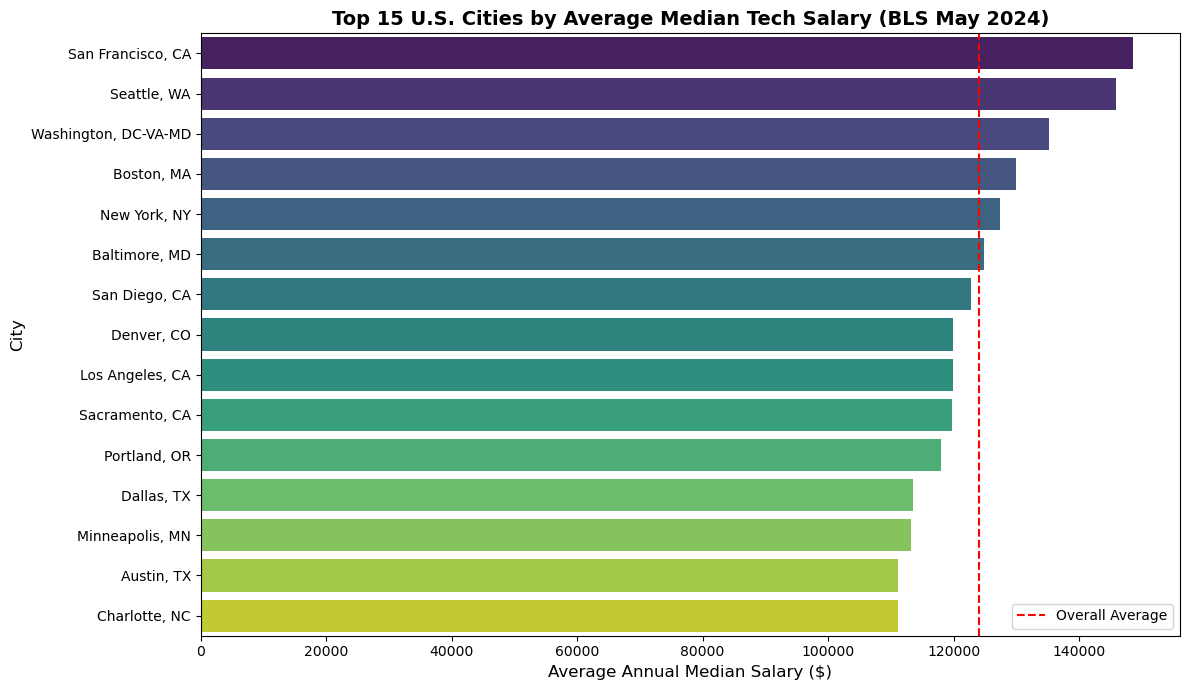

In [27]:
# Visual 1: Top 15 Cities by Median Tech Salary

import matplotlib.pyplot as plt
import seaborn as sns

# Convert A_MEDIAN to numeric first to ensure no type issues
combined_df['A_MEDIAN'] = pd.to_numeric(combined_df['A_MEDIAN'], errors='coerce')

# Calculate average median salary per city
city_salary = combined_df.groupby('City')['A_MEDIAN'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=city_salary.values, y=city_salary.index,
            hue=city_salary.index, palette='viridis', legend=False)
plt.title('Top 15 U.S. Cities by Average Median Tech Salary (BLS May 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Average Annual Median Salary ($)', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.axvline(x=city_salary.mean(), color='red', linestyle='--', label='Overall Average')
plt.legend()
plt.tight_layout()
plt.savefig('viz1_top_cities_by_salary.png', dpi=150)
plt.show()

*This visualization shows that San Francisco, CA and Seattle, WA offer the highest average median tech salaries, significantly above the overall average marked by the red dashed line. However, high salaries alone do not tell the complete story — cities like Baltimore, MD and Portland, OR appear competitive on salary but may offer better value once cost of living is considered, which is explored in Visual 2.*

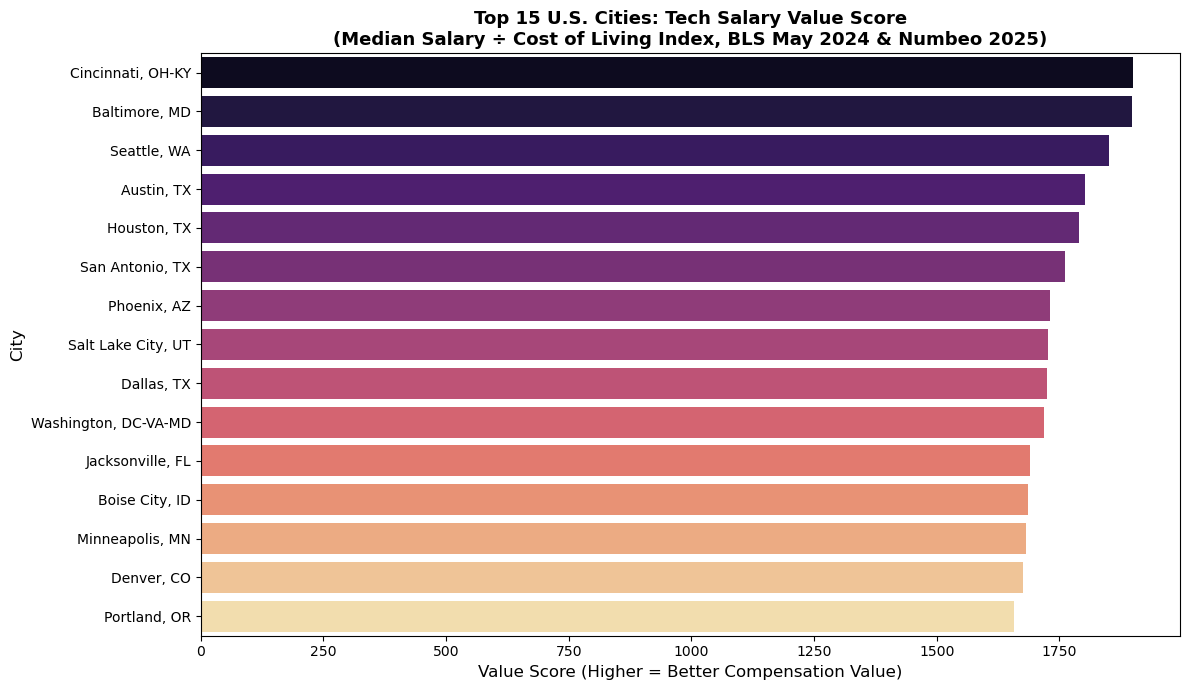

In [28]:
# Visual 2: Salary-to-Cost-of-Living Ratio by City
# Higher ratio = better value for tech workers

# Calculate average salary and cost of living per city
# Visual 2: Salary-to-Cost-of-Living Ratio by City
# Higher ratio = better value for tech workers

# Ensure numeric types
combined_df['A_MEDIAN'] = pd.to_numeric(combined_df['A_MEDIAN'], errors='coerce')
combined_df['Cost of Living Index'] = pd.to_numeric(combined_df['Cost of Living Index'], errors='coerce')

# Calculate average salary and cost of living per city
city_data = combined_df.groupby('City').agg(
    Avg_Salary=('A_MEDIAN', 'mean'),
    Cost_of_Living=('Cost of Living Index', 'mean')
).reset_index()

# Create salary-to-cost ratio (value score)
city_data['Value_Score'] = city_data['Avg_Salary'] / city_data['Cost_of_Living']

# Sort by value score
city_data = city_data.sort_values('Value_Score', ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x='Value_Score', y='City', data=city_data,
            hue='City', palette='magma', legend=False)
plt.title('Top 15 U.S. Cities: Tech Salary Value Score\n(Median Salary ÷ Cost of Living Index, BLS May 2024 & Numbeo 2025)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Value Score (Higher = Better Compensation Value)', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.tight_layout()
plt.savefig('viz2_salary_value_score.png', dpi=150)
plt.show()


*This visualization reveals that the highest-paying cities are not necessarily the best value for tech workers. Cincinnati, OH and Baltimore, MD offer the highest salary-to-cost-of-living ratio, meaning tech workers' dollars stretch furthest there. Notably, Texas cities Austin, Houston, San Antonio, and Dallas all rank in the top 10, likely benefiting from no state income tax and relatively moderate living costs. San Francisco, despite having the highest raw salaries, does not appear in the top 15 value cities, confirming that its extreme cost of living erodes compensation advantage significantly.* 

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Given more time, I would expand the Numbeo dataset to include all U.S. cities rather than the 38 currently available, which would allow for a more comprehensive geographic analysis across smaller and emerging tech markets. I would also incorporate additional variables such as state income tax rates, remote work prevalence by city, and year-over-year salary growth trends to build a more complete picture of tech worker compensation value. Additionally, I would explore machine learning models to predict which cities are likely to offer the best compensation value in the coming years based on economic indicators. Finally, I would investigate occupation-specific trends to determine whether certain tech roles such as Data Scientists or Information Security Analysts consistently outperform others regardless of location.* 